In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/flipkart-product/flipkart_product_copy.csv


In [2]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

In [3]:
df = pd.read_csv('/kaggle/input/flipkart-product/flipkart_product_copy.csv',encoding='latin1')

# Preprocess the data
# Convert Rate to numeric and handle any errors
df['Rate'] = pd.to_numeric(df['Rate'], errors='coerce')

# Drop rows with missing Rate values
df = df.dropna(subset=['Rate'])

# Map ratings to sentiment categories
def map_sentiment(rate):
    if rate > 3:
        return 'Positive'
    elif rate < 3:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment'] = df['Rate'].apply(map_sentiment)

# Combine Review and Summary for better analysis
df['text'] = df['Summary'] + ' ' + df['Review']

# Define a more comprehensive set of stopwords
english_stopwords = {
    'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', 'your', 
    'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', 
    'her', 'hers', 'herself', 'it', 'its', 'itself', 'they', 'them', 'their', 
    'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that', 
    'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 
    'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an', 
    'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', 
    'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 
    'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 
    'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 
    'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 
    'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 
    'only', 'own', 'same', 'so', 'than', 'too', 'very', 's', 't', 'can', 
    'will', 'just', 'don', "don't", 'should', 'now', 'd', 'll', 'm', 'o', 're', 
    've', 'y', 'ain', 'aren', "aren't", 'couldn', "couldn't", 'didn', "didn't", 
    'doesn', "doesn't", 'hadn', "hadn't", 'hasn', "hasn't", 'haven', "haven't", 
    'isn', "isn't", 'ma', 'mightn', "mightn't", 'mustn', "mustn't", 'needn', 
    "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't", 
    'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"
}

# Words that shouldn't be removed as they're important for sentiment
sentiment_words = {
    'not', 'no', 'never', 'none', 'nobody', 'nothing', 'nowhere', 'neither', 
    'nor', 'hardly', 'scarcely', 'barely', 'but', 'however', 'although', 
    'though', 'despite', 'except', 'unless', 'until', 'without'
}

for word in sentiment_words:
    if word in english_stopwords:
        english_stopwords.remove(word)


In [4]:
def preprocess_text(text):
    if pd.isna(text) or text is None:
        return ""
    
    # Convert to string and lowercase
    text = str(text).lower()
    
    # Remove special characters but keep basic punctuation that might indicate sentiment
    text = re.sub(r"[^a-zA-Z0-9!?.,'\s]", '', text)
    
    # Expand contractions
    contractions = {
        "won't": "will not", "can't": "can not", "n't": " not", "'re": " are",
        "'s": " is", "'d": " would", "'ll": " will", "'t": " not", "'ve": " have",
        "'m": " am"
    }
    for contraction, expansion in contractions.items():
        text = text.replace(contraction, expansion)
    
    # Tokenize
    words = re.findall(r"\b\w+(?:'\w+)?\b", text)
    
    # Remove stopwords but keep important sentiment modifiers
    filtered_words = [word for word in words if word not in english_stopwords]
    
    # Enhanced negation handling
    result = []
    negate = False
    negators = {'not', 'no', 'never', 'none', 'nobody', 'nothing', 'nowhere', 
                'neither', 'nor', 'hardly', 'scarcely', 'barely'}
    
    for word in filtered_words:
        if word in negators:
            negate = True
            result.append(word)
        elif negate:
            result.append('NOT_' + word)
            negate = False
        else:
            result.append(word)
    
    # Rejoin words
    return ' '.join(result)

In [5]:
df['processed_text'] = df['text'].apply(preprocess_text)

# Check class distribution
print("Class distribution:")
print(df['sentiment'].value_counts())

# Handle class imbalance with SMOTE
X = df['processed_text']
y = df['sentiment']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature extraction with TF-IDF
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),  # Use both unigrams and bigrams
    min_df=5,           # Only include terms that appear in at least 5 documents
    max_df=0.8,         # Ignore terms that appear in more than 80% of documents
    sublinear_tf=True,  # Use sublinear tf scaling
    stop_words=list(english_stopwords)
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Apply SMOTE only to the training data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_vec, y_train)


Class distribution:
sentiment
Positive    148347
Negative     25841
Neutral      15681
Name: count, dtype: int64



Training and tuning Logistic Regression...
Best parameters: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
Logistic Regression Accuracy: 0.9362

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

    Negative       0.96      0.96      0.96      5168
     Neutral       0.60      0.88      0.71      3136
    Positive       0.99      0.94      0.96     29670

    accuracy                           0.94     37974
   macro avg       0.85      0.93      0.88     37974
weighted avg       0.95      0.94      0.94     37974



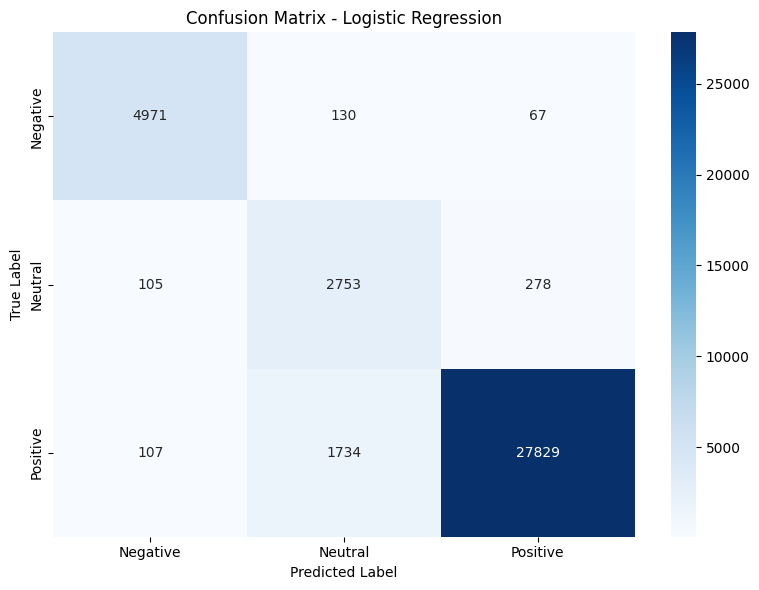


Training and tuning Naive Bayes...
Best parameters: {'alpha': 0.1}
Naive Bayes Accuracy: 0.9141

Classification Report for Naive Bayes:
              precision    recall  f1-score   support

    Negative       0.94      0.95      0.94      5168
     Neutral       0.51      0.81      0.62      3136
    Positive       0.98      0.92      0.95     29670

    accuracy                           0.91     37974
   macro avg       0.81      0.89      0.84     37974
weighted avg       0.94      0.91      0.92     37974



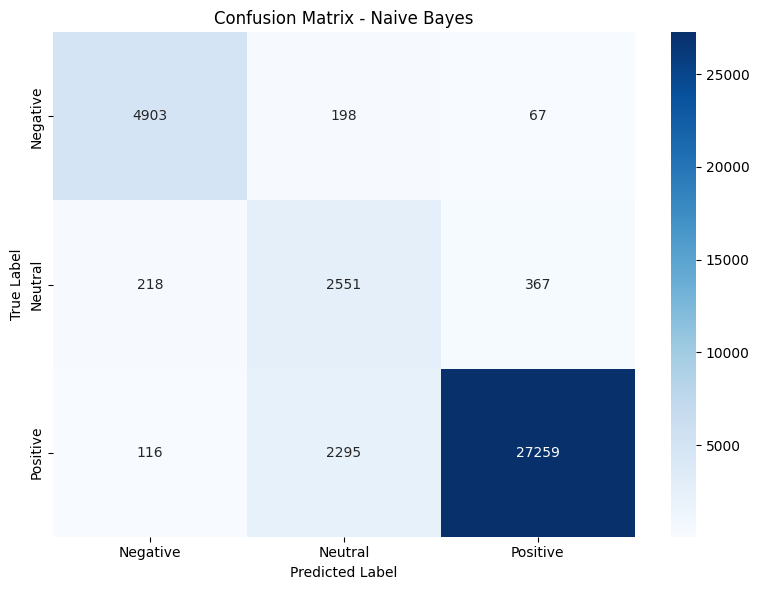


Training and tuning SVM...


/usr/local/lib/python3.10/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Best parameters: {'C': 10, 'loss': 'hinge'}
SVM Accuracy: 0.9348

Classification Report for SVM:
              precision    recall  f1-score   support

    Negative       0.96      0.96      0.96      5168
     Neutral       0.59      0.88      0.71      3136
    Positive       0.99      0.94      0.96     29670

    accuracy                           0.93     37974
   macro avg       0.85      0.92      0.88     37974
weighted avg       0.95      0.93      0.94     37974



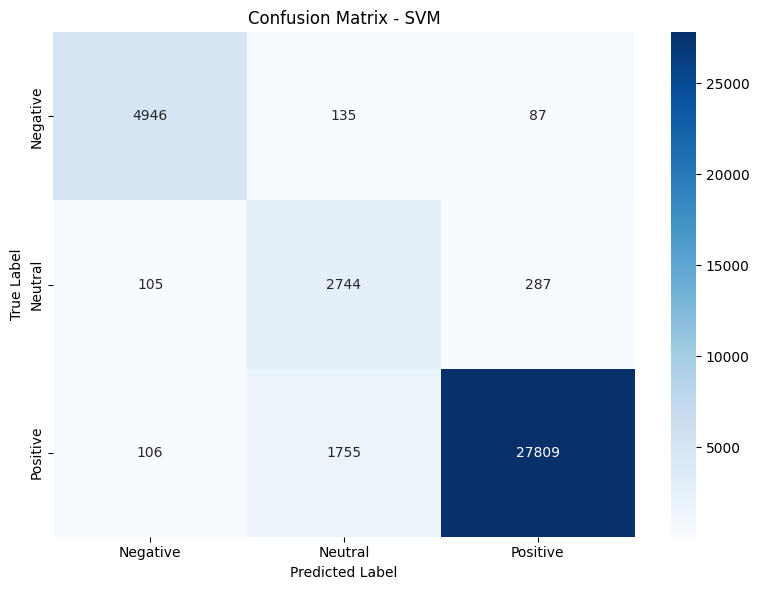

In [7]:
models = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, random_state=42),
        'params': {
            'C': [0.1, 1, 10],
            'penalty': ['l1', 'l2'],
            'solver': ['liblinear']
        }
    },
    'Naive Bayes': {
        'model': MultinomialNB(),
        'params': {
            'alpha': [0.1, 0.5, 1.0]
        }
    },
    'SVM': {
        'model': LinearSVC(random_state=42, max_iter=1000),
        'params': {
            'C': [0.1, 1, 10],
            'loss': ['hinge', 'squared_hinge']
        }
    }
}

best_models = {}
results = {}

for name, config in models.items():
    print(f"\nTraining and tuning {name}...")
    
    # Perform grid search
    grid = GridSearchCV(
        config['model'], 
        config['params'], 
        cv=5, 
        scoring='accuracy',
        n_jobs=-1
    )
    grid.fit(X_train_res, y_train_res)
    
    # Get the best model
    best_model = grid.best_estimator_
    best_models[name] = best_model
    
    # Evaluate on test set
    y_pred = best_model.predict(X_test_vec)
    accuracy = accuracy_score(y_test, y_pred)
    
    print(f"Best parameters: {grid.best_params_}")
    print(f"{name} Accuracy: {accuracy:.4f}")
    
    # Store results
    results[name] = {
        'model': best_model,
        'accuracy': accuracy,
        'predictions': y_pred,
        'best_params': grid.best_params_
    }
    print(f"\nClassification Report for {name}:")
    print(classification_report(y_test, y_pred))
    
    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Negative', 'Neutral', 'Positive'], 
                yticklabels=['Negative', 'Neutral', 'Positive'])
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{name.lower().replace(" ", "_")}.png')
    plt.show()


In [8]:
best_model_name = max(results, key=lambda x: results[x]['accuracy'])
best_model = results[best_model_name]['model']
best_accuracy = results[best_model_name]['accuracy']
print(f"\nBest Model: {best_model_name} with accuracy {best_accuracy:.4f}")

# Save the best model and vectorizer
joblib.dump(best_model, 'best_sentiment_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')
print("Model and vectorizer saved to disk.")



Best Model: Logistic Regression with accuracy 0.9362
Model and vectorizer saved to disk.


In [9]:
class SentimentAnalyzer:
    def __init__(self, model, vectorizer):
        self.model = model
        self.vectorizer = vectorizer
        
    def predict_sentiment(self, text):
        # Preprocess the text
        processed = preprocess_text(text)
        
        # Vectorize
        features = self.vectorizer.transform([processed])
        
        # Predict
        prediction = self.model.predict(features)[0]
        
        # Get confidence scores
        confidence = "N/A"
        if hasattr(self.model, 'predict_proba'):
            probabilities = self.model.predict_proba(features)[0]
            confidence = max(probabilities) * 100
        elif isinstance(self.model, LinearSVC):
            decision_scores = self.model.decision_function(features)
            confidence = (1 / (1 + np.exp(-abs(decision_scores)))) * 100
            if isinstance(confidence, np.ndarray):
                confidence = float(confidence[0])
        
        # Convert sentiment to rating
        rating = 1 if prediction == 'Negative' else 3 if prediction == 'Neutral' else 5
        
        return prediction, rating, confidence

# Initialize the analyzer
analyzer = SentimentAnalyzer(best_model, vectorizer)


In [12]:
def user_interface():
    print("\n" + "="*50)
    print("Flipkart Review Sentiment Analyzer")
    print("="*50)
    print("Enter a product review to analyze its sentiment (or 'quit' to exit)")
    print("Sentiment Classification:")
    print("- Positive (Rating > 3)")
    print("- Neutral (Rating = 3)")
    print("- Negative (Rating < 3)")
    
    while True:
        user_input = input("\nEnter your review: ").strip()
        
        if user_input.lower() in ['quit', 'exit']:
            print("\nThank you for using the Sentiment Analyzer. Goodbye!")
            break
        
        if not user_input:
            print("Please enter a valid review.")
            continue
        
        # Analyze sentiment
        sentiment, rating, confidence = analyzer.predict_sentiment(user_input)
        
        # Display results
        print("\nSentiment Analysis Results:")
        print("-" * 30)
        print(f"Review: {user_input}")
        print(f"Sentiment: {sentiment}")
        print(f"Rating: {rating}/5")
        if confidence != "N/A":
            print(f"Confidence: {confidence:.2f}%")
        
        # Display a simple visualization
        sentiment_bar = "■" * int(rating)
        empty_bar = "□" * (5 - int(rating))
        print(f"\nRating: [{sentiment_bar}{empty_bar}] {rating}/5")
        
        # Provide interpretation
        if rating > 3:
            print("\nThis is a POSITIVE review! 😊")
        elif rating < 3:
            print("\nThis is a NEGATIVE review! 😞")
        else:
            print("\nThis is a NEUTRAL review. 😐")

# Start the user interface
if __name__ == "__main__":
    user_interface()


Flipkart Review Sentiment Analyzer
Enter a product review to analyze its sentiment (or 'quit' to exit)
Sentiment Classification:
- Positive (Rating > 3)
- Neutral (Rating = 3)
- Negative (Rating < 3)



Enter your review:  This grocery item is fresh and good in taste.



Sentiment Analysis Results:
------------------------------
Review: This grocery item is fresh and good in taste.
Sentiment: Positive
Rating: 5/5
Confidence: 84.76%

Rating: [■■■■■] 5/5

This is a POSITIVE review! 😊



Enter your review:  This product is in bad condition.



Sentiment Analysis Results:
------------------------------
Review: This product is in bad condition.
Sentiment: Negative
Rating: 1/5
Confidence: 99.80%

Rating: [■□□□□] 1/5

This is a NEGATIVE review! 😞



Enter your review:  Exit



Thank you for using the Sentiment Analyzer. Goodbye!
